# Predictive Model Generation with Decision Tree: Crocodile Dataset Practice
### Decision Tree Classifier
---

**Author** Iván Jarpa Manríquez | Senior Data Analyst & AI Agent Developer |
**Date** September 2026 |
**Objective** Build and evaluate a Decision Tree Classifier to predict the conservation status in the crocodile dataset. |
**Dataset** Crocodile Dataset (`crocodile_dataset.csv`)

---

## Table of Contents
1. [Enviroment Setup & Data Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Data Preprocessing](#3)
4. [Model Training (Decision Tree)](#4)
5. [Model Evaluation](#5)
5. [Feature Importance & Conclusions](#6)

---

## 1. Enviroment Setup & Data Loading
In this section, we import all required libraries for data manipulation, visualization, modeling, and evaluation. We also load the dataset into memory.

In [ ]:
# Data manipulation and numerical operations
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Scikit-Learn modules
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# load the dataset
crocoset = pd.read_csv("/kaggle/input/datasets/zadafiyabhrami/global-crocodile-species-dataset/crocodile_dataset.csv", index_col=0)

# Quick preview
crocoset.head()

,Common Name,Scientific Name,Family,Genus,Observed Length (m),Observed Weight (kg),Age Class,Sex,Date of Observation,Country/Region,Habitat Type,Conservation Status,Observer Name,Notes
Observation ID,,,,,,,,,,,,,,
1,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,1.90,62.0,Adult,Male,31-03-2018,Belize,Swamps,Least Concern,Allison Hill,Cause bill scientist nation opportunity.
2,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,4.09,334.5,Adult,Male,28-01-2015,Venezuela,Mangroves,Vulnerable,Brandon Hall,Ago current practice nation determine operatio...
3,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,1.08,118.2,Juvenile,Unknown,07-12-2010,Venezuela,Flooded Savannas,Critically Endangered,Melissa Peterson,Democratic shake bill here grow gas enough ana...
4,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,2.42,90.4,Adult,Male,01-11-2019,Mexico,Rivers,Least Concern,Edward Fuller,Officer relate animal direction eye bag do.
5,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,3.75,269.4,Adult,Unknown,15-07-2019,India,Rivers,Vulnerable,Donald Reid,Class great prove reduce raise author play mov...


## 2. Exploratory Data Analysis (EDA)
In this section, we inspect the dataset structure, statistical summaries, missing values, and the target variable distribution (`conservation_status`).

### Dataset Dimensions & Data Types
Checking the shape of the dataset and inspecting the data type of each feature.

In [4]:
crocoset.shape

(1000, 14)

In [5]:
crocoset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 1 to 1000
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Common Name           1000 non-null   str    
 1   Scientific Name       1000 non-null   str    
 2   Family                1000 non-null   str    
 3   Genus                 1000 non-null   str    
 4   Observed Length (m)   1000 non-null   float64
 5   Observed Weight (kg)  1000 non-null   float64
 6   Age Class             1000 non-null   str    
 7   Sex                   1000 non-null   str    
 8   Date of Observation   1000 non-null   str    
 9   Country/Region        1000 non-null   str    
 10  Habitat Type          1000 non-null   str    
 11  Conservation Status   1000 non-null   str    
 12  Observer Name         1000 non-null   str    
 13  Notes                 1000 non-null   str    
dtypes: float64(2), str(12)
memory usage: 109.5 KB


### Missing Values Inspection
Verifying if there are any null or missing values across features.

>**Note:** Checking for missing values is performed here primarily for educational and validation purposes, as the dataset does not contain missin or null data.

In [6]:
crocoset.isnull().sum()

Common Name             0
Scientific Name         0
Family                  0
Genus                   0
Observed Length (m)     0
Observed Weight (kg)    0
Age Class               0
Sex                     0
Date of Observation     0
Country/Region          0
Habitat Type            0
Conservation Status     0
Observer Name           0
Notes                   0
dtype: int64

### Summary Statistics
Computing descriptive statistic for numerical variables (mean, standar deviation, min, max).

In [7]:
crocoset.describe()

,Observed Length (m),Observed Weight (kg)
count,1000.000000,1000.000000
mean,2.415110,155.771900
std,1.097542,175.186788
min,0.140000,4.400000
25%,1.637500,53.225000
50%,2.430000,100.600000
75%,3.010000,168.875000
max,6.120000,1139.700000


### Target Variable Distribution and Visualization (`conservation status`)
Analyzing class balance to identify potential class imbalancing in the dataset.

In [8]:
crocoset["Conservation Status"].value_counts()

Conservation Status
Least Concern            384
Critically Endangered    275
Vulnerable               170
Data Deficient           115
Endangered                56
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

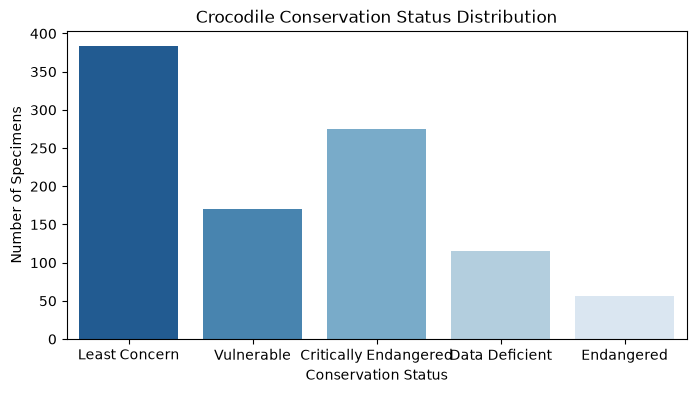

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=crocoset, 
    x="Conservation Status", 
    hue="Conservation Status", 
    palette="Blues_r", 
    legend=False)

plt.title("Crocodile Conservation Status Distribution")
plt.xlabel("Conservation Status")
plt.ylabel("Number of Specimens")
plt.show

> **Interpretation:** The target variable shows significant class imbalance, with `Least Concern` dominating the dataset (384 specimens) while `Endangered` represent a minority class (56 specimens). To mitigate bias during training, we will user stratified splitting and class weight balancing.

## 3. Data Preprocessing and Feature Engineering
In this section, we prepare the dataset for model training. This includes separating features from the target variable, performing a stratified train-test split, and encoding categorical variables into numerical format **after** the split to prevent data leakage.

### Feature Matrix ($x$) and Target Vector ($y$) Separation
Isolating the predictor features from the categorical target variable (`Conservation Status`).
To ensure optimal model generalization and prevent overfitting, we prune columns based on cardinality extremes:
* **High-Cardinality/Text Features:** Dropped unique identifiers, names, dates, and free-form notes (e.g., `Common Name`, `Scientific Name`, `Observer Name`, `Date of Observation`, `Notes`) to avoid target leakage and memory inflation.
* **Proxy Features:** Dropped `Country/Region` and `Habitat Type`. In this dataset, `Conservation Status` is a fixed attribute of the species (not the individual), and both geographic variables turned out to be near 1:1 proxies for species identity — keeping them let the model shortcut the biological signal entirely, inflating accuracy without learning anything meaningful.
* **Predictive Set:** Retained key biological measurements (`Observed Length`, `Observed Weight`) and demographics (`Age Class`, `Sex`).

In [10]:
x = crocoset.drop(columns=[
    "Conservation Status",
    "Common Name",
    "Scientific Name",
    "Family",
    "Genus",
    "Date of Observation",
    "Observer Name",
    "Notes",
    "Country/Region",
    "Habitat Type"
    ])

y = crocoset["Conservation Status"]

### Stratified Train-Test Split
Splitting the dataset into 80% training and 20% testing sets. We apply `stratify=y` to preserve the imbalanced class proportions across both sets.

> **Order note:** The split is performed **before** categorical encoding. Fitting `pd.get_dummies` on the full dataset first would let the test set influence the feature space seen during training (i.e. the model would train being aware of the complete universe of categories, some coming only from the held-out test set) — a subtle form of data leakage.

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=777, stratify=y
)

### Categorical Feature Encoding
Applying one-hot encoding (`pd.get_dummies`) to ensure all predictor features are strictly numerical for Scikit-Learn algorithms. Encoding is fitted separately on `x_train` and `x_test` so no information from the test set leaks into the training feature space.

> **Column alignment:** since `x_train` and `x_test` are encoded independently, a category present in only one of the two sets would otherwise produce mismatched dummy columns. We reindex `x_test` against `x_train`'s columns (filling missing ones with `0`) so both sets share the exact same feature space the model was fit on.

In [12]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

## 4. Model Training (Decision Tree)
In this section, we instantiate and train the Decision Tree Classifier using the preprocesed training dataset (`x_train`,`y_train`).

### Model Instantiation & Hyperparameter Setup
Configuring the `DecisionTreeClassifier` with `class_weight='balanced'` to handle class imbalance and setting `random_state=777` for exact reproducibility.

> **Overfitting note:** unlike Random Forest, a single Decision Tree left unconstrained (no `max_depth`, `min_samples_leaf`, etc.) will keep splitting until it perfectly memorizes the training set — high variance, near-zero bias on train, and a real risk of overfitting on test. We start with the defaults here (no pruning) to see that behaviour directly; constraining depth is a natural next experiment for this template.

In [13]:
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=777)

### Model Fitting
Training the algorithm on the training dataset

In [14]:
dt_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",777
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are

## 5. Model Evaluation
In this section, we evaluate the trained Decision Tree model on the unseen test set (`x_test`). We assess overall accuracy, detailed class metrics via a clasification report, and a confusion matrix visualization.

### Model Predictions
Generating predictions for the test datasets.

In [15]:
y_pred = dt_model.predict(x_test)

### Clasification Metrics
Computing precision, recall, F1-score, and support  for each conservation status class.

In [16]:
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.4850

                       precision    recall  f1-score   support

Critically Endangered       0.45      0.53      0.48        55
       Data Deficient       0.25      0.22      0.23        23
           Endangered       0.00      0.00      0.00        11
        Least Concern       0.60      0.55      0.57        77
           Vulnerable       0.62      0.62      0.62        34

             accuracy                           0.48       200
            macro avg       0.38      0.38      0.38       200
         weighted avg       0.49      0.48      0.48       200



### Confusion Matrix Visualization
Visualizing true versus predicted classifications to identify specific misclassifications across target classes.

<Figure size 800x600 with 0 Axes>

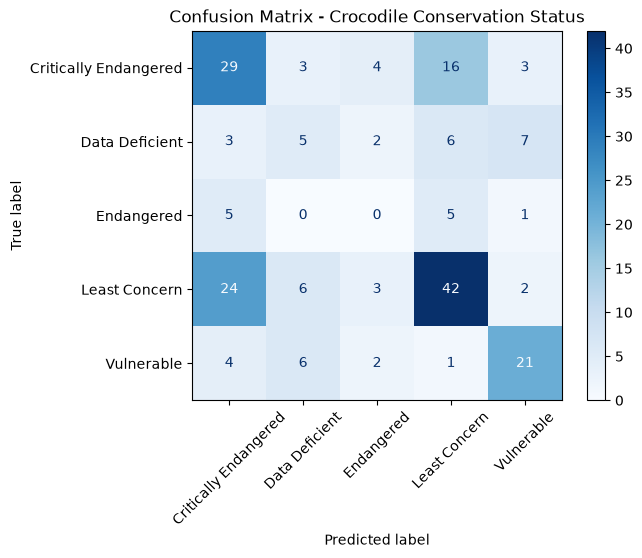

In [17]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Blues", xticks_rotation=45
)
plt.title("Confusion Matrix - Crocodile Conservation Status")
plt.show()

### Feature Importance Analysis & Leakage Verification
Evaluating the Gini importance of individual features to ensure balanced decision-making across predictors and verify the absence of target leakage after removing high-cardinality and proxy variables.

In [18]:
feature_importances = pd.Series(
    dt_model.feature_importances_, index=x_train.columns
).sort_values(ascending=False)
print(feature_importances)

Observed Weight (kg)    0.476588
Observed Length (m)     0.380250
Sex_Unknown             0.044926
Age Class_Subadult      0.037359
Sex_Male                0.032150
Age Class_Juvenile      0.020079
Age Class_Hatchling     0.008649
dtype: float64


> **Verification Note:** After removing taxonomic identifiers and the geographic proxy variables (`Country/Region`, `Habitat Type`), feature importance is distributed strictly across the remaining biological and demographic parameters (`Observed Length`, `Observed Weight`, `Age Class`, `Sex`). Compare this single tree's importances and accuracy against the Random Forest version of this notebook — a single unconstrained tree tends to lean harder on fewer splits and is more sensitive to the specific `random_state`, which is exactly what makes it a good teaching tool for understanding what the ensemble is averaging over.